It's possible that the only reason the logistic regression model works is because of a difference in behaviour, rather than an interesting difference in the neural space. Even if we fail to correlate a difference in behavioural distributions with decoding accuracy, the brain might maximally encode the behavioural information so a single chunck of information is sufficient regardless. Thus if we subsample sessions with a lot of data in, we can ensure there are limited behavioural differences and any decoding accuracy is a result of either a non-ovbious behavioural difference, or a difference in neural space such as an encoding of a cognitive map.

Null hypothesis: The decoding effect is an artefact of behavioural differences, subsampling the behaviour will remove this effect and accuracy will drop to 50%. 

Subsampling method: 
- In order to subsample, first select only sessions with 800 frames of data (400 per class / 10 seconds per class etc / 20 homings per class)
- Then for each of the behavioural variables of interest (e.g: behaviours_to_subsample = ["mouse_x_position", "mouse_y_position", "speed", "hdir", "hsa"]) find the intersection of the “good” homings vs “bad” homings
- Do this one behaviour at a time, leaving the other behaviours untouched


In [12]:
from collections import defaultdict
import pickle
from pathlib import Path

from loguru import logger
import matplotlib.pyplot as plt
import numpy as np

from behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.model import compute_down_sampled_accuracy_data

In [13]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may, JAL8_flip3_7may

In [14]:
experiments_objects = [JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may, JAL8_flip3_7may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

In [15]:
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency")
name_of_data = "compute_the_first_20_frames_before_homing"
path = dir / f"{name_of_data}.pkl"
with open(path, "rb") as f:
    compute_the_first_20_frames_before_homing =  pickle.load(f)

Generate the subsampled data - Takes about 40 minutes

In [22]:
behaviours_to_subsample = ["mouse_x_position", "mouse_y_position", "speed", "hdir", "hsa"] # Which behaviours are we worried may cause the model to fit over real neural differences

# Uncomment this if generating the data for the first time

# sub_sample_accuracy_data = defaultdict(dict)
# for behaviour in behaviours_to_subsample:
#     logger.info(f"Computing accuracy data for {behaviour}")
#     sub_sample_accuracy_data[behaviour] = compute_down_sampled_accuracy_data(
#         data_type=compute_the_first_20_frames_before_homing, 
#         experiments_objects= experiments_objects, 
#         behaviour_to_subsample=behaviour
#     )
# # Save the data
# path = dir / f"sub_sample_accuracy_data.pkl"
# with open(path, "wb") as f:
#     pickle.dump(sub_sample_accuracy_data, f)

# Load the data
with open(path, "rb") as f:
    sub_sample_accuracy_data = pickle.load(f)  # Use the file object directly for loading

print(sub_sample_accuracy_data)

defaultdict(<class 'dict'>, {'mouse_x_position': defaultdict(<class 'float'>, {'JAL6_flip3_18mar': np.float64(0.558695652173913), 'JAL6_flip4_21mar': np.float64(0.5261021044084176), 'JAL8_flip4_10may': np.float64(0.58125), 'JAL8_14may': np.float64(0.65625), 'JAL8_flip3_7may': np.float64(0.65)}), 'mouse_y_position': defaultdict(<class 'float'>, {'JAL6_flip3_18mar': np.float64(0.5489130434782609), 'JAL6_flip4_21mar': np.float64(0.5170720682882731), 'JAL8_flip4_10may': np.float64(0.52125), 'JAL8_14may': np.float64(0.6392857142857142), 'JAL8_flip3_7may': np.float64(0.7097222222222221)}), 'speed': defaultdict(<class 'float'>, {'JAL6_flip3_18mar': np.float64(0.6184782608695651), 'JAL6_flip4_21mar': np.float64(0.5520342081368326), 'JAL8_flip4_10may': np.float64(0.5549999999999999), 'JAL8_14may': np.float64(0.6723214285714285), 'JAL8_flip3_7may': np.float64(0.6583333333333333)}), 'hdir': defaultdict(<class 'float'>, {'JAL6_flip3_18mar': np.float64(0.5978260869565217), 'JAL6_flip4_21mar': np.fl

Access previously saved accuracy data

In [17]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\500ms_before_accuracy\500ms_before_accuracy_accuracy_ks_coeffs_data.pkl", "rb") as f:
    accuracy_ks_coeffs_data = pickle.load(f)
model_accuracy = accuracy_ks_coeffs_data["accuracy_data"]

Plot bar plot showing model accuracy vs when we downsample each behaviour individually

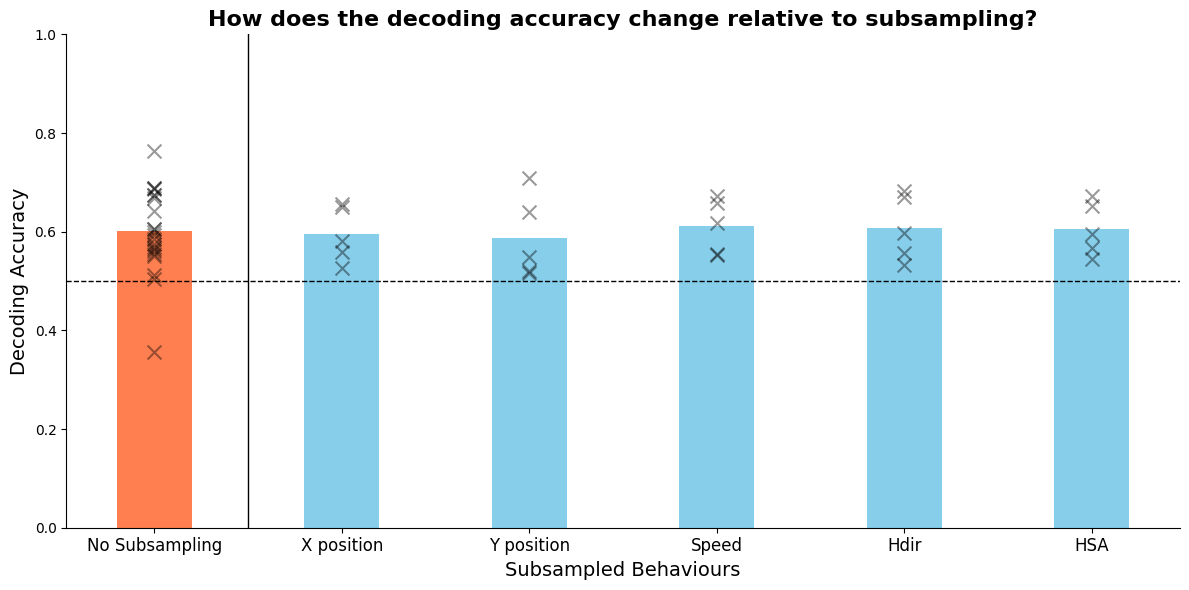

In [18]:
# Data Generation
x_labels = ["No Subsampling", "X position", "Y position", "Speed", "Hdir", "HSA"] # Define labels for what we want to plot
avg_accuracy = np.mean(list(model_accuracy.values())) # Get the average accuracy across all sessions with no subsampling
mouse_x_acc = np.mean([acc for acc in sub_sample_accuracy_data["mouse_x_position"].values()]) # Get the average accuracy for each subsampled behaviour
mouse_y_acc = np.mean([acc for acc in sub_sample_accuracy_data["mouse_y_position"].values()])
hdir_acc = np.mean([acc for acc in sub_sample_accuracy_data["hdir"].values()])
hsa_acc = np.mean([acc for acc in sub_sample_accuracy_data["hsa"].values()])
speed_acc = np.mean([acc for acc in sub_sample_accuracy_data["speed"].values()])
y_values = [avg_accuracy, mouse_x_acc, mouse_y_acc, speed_acc, hdir_acc, hsa_acc]

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x_positions = np.arange(len(x_labels))
ax.bar(x_positions, y_values, bar_width, color='skyblue')
ax.set_title("How does the decoding accuracy change relative to subsampling?", fontsize=16, fontweight='bold')
ax.set_ylabel("Decoding Accuracy", fontsize=14)
ax.set_xlabel("Subsampled Behaviours", fontsize=14)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, ha='center', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([0, 1])
ax.patches[0].set_facecolor('coral') # Change the colour of the first bar to coral
plt.scatter([x_positions[0]] * len(model_accuracy.values()), model_accuracy.values(), color='black', alpha=0.4, marker="x", s=100, label='Model Accuracy') # Add the model accuracy data points 

# Next add the sub sampled data points
for i, (behaviour, data) in enumerate(sub_sample_accuracy_data.items()):
    y_values = [acc for acc in data.values()]
    plt.scatter([x_positions[i + 1]] * len(y_values), y_values, color='black', marker="x", alpha=0.4, s=100, label=f'{behaviour} Accuracy')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1) # Chance level
ax.axvline(x=0.5, color='black', linestyle='-', linewidth=1) # Get the average accuracy for each subsampled behaviour 
plt.tight_layout()
plt.show()